<a href="https://colab.research.google.com/github/praveenkumarrlgmp-source/AIML-final-project/blob/main/AIML_final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving ABB_minute.csv to ABB_minute.csv


In [2]:
import os

print(os.listdir("/content"))

['.config', 'ABB_minute.csv', 'sample_data']


In [3]:
!pip install -q pandas numpy matplotlib scikit-learn tensorflow

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


In [5]:
file_path = "/content/ABB_minute.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Rows and columns:", df.shape)

Dataset loaded successfully!
Rows and columns: (1031866, 6)


In [6]:
df.head()

,date,open,high,low,close,volume
0,2015-02-02 09:15:00,1000.85,1005.50,1000.85,1004.40,7478
1,2015-02-02 09:16:00,1004.40,1008.65,1003.90,1004.00,333
2,2015-02-02 09:17:00,1004.00,1007.25,1001.05,1003.90,542
3,2015-02-02 09:18:00,1003.90,1005.35,1003.90,1005.00,51
4,2015-02-02 09:19:00,1005.00,1008.65,1003.40,1005.05,260


In [7]:
print(df.columns.tolist())

['date', 'open', 'high', 'low', 'close', 'volume']


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1031866 entries, 0 to 1031865
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   date    1031866 non-null  object 
 1   open    1031866 non-null  float64
 2   high    1031866 non-null  float64
 3   low     1031866 non-null  float64
 4   close   1031866 non-null  float64
 5   volume  1031866 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 47.2+ MB


In [9]:
print(df.describe())

               open          high           low         close        volume
count  1.031866e+06  1.031866e+06  1.031866e+06  1.031866e+06  1.031866e+06
mean   2.531384e+03  2.532833e+03  2.529891e+03  2.531372e+03  5.634746e+02
std    2.126171e+03  2.127406e+03  2.124913e+03  2.126157e+03  3.069706e+03
min    7.243500e+02  7.250000e+02  7.223500e+02  7.243500e+02  0.000000e+00
25%    1.002400e+03  1.003100e+03  1.001750e+03  1.002400e+03  3.400000e+01
50%    1.226850e+03  1.227500e+03  1.226000e+03  1.226800e+03  1.530000e+02
75%    4.087700e+03  4.090000e+03  4.085450e+03  4.087700e+03  4.880000e+02
max    9.149950e+03  9.149950e+03  9.113000e+03  9.131600e+03  6.808380e+05


In [10]:
print(df.isnull().sum())

date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [12]:
df["date"] = pd.to_datetime(df["date"])

print(df["date"].head())

0   2015-02-02 09:15:00
1   2015-02-02 09:16:00
2   2015-02-02 09:17:00
3   2015-02-02 09:18:00
4   2015-02-02 09:19:00
Name: date, dtype: datetime64[ns]


In [13]:
df = df.sort_values("date")

df = df.reset_index(drop=True)

print(df.head())

                 date     open     high      low    close  volume
0 2015-02-02 09:15:00  1000.85  1005.50  1000.85  1004.40    7478
1 2015-02-02 09:16:00  1004.40  1008.65  1003.90  1004.00     333
2 2015-02-02 09:17:00  1004.00  1007.25  1001.05  1003.90     542
3 2015-02-02 09:18:00  1003.90  1005.35  1003.90  1005.00      51
4 2015-02-02 09:19:00  1005.00  1008.65  1003.40  1005.05     260


In [14]:
df = df.drop_duplicates()

df = df.dropna()

df = df.reset_index(drop=True)

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (1031866, 6)


In [15]:
df.head(10)

,date,open,high,low,close,volume
0,2015-02-02 09:15:00,1000.85,1005.50,1000.85,1004.40,7478
1,2015-02-02 09:16:00,1004.40,1008.65,1003.90,1004.00,333
2,2015-02-02 09:17:00,1004.00,1007.25,1001.05,1003.90,542
3,2015-02-02 09:18:00,1003.90,1005.35,1003.90,1005.00,51
4,2015-02-02 09:19:00,1005.00,1008.65,1003.40,1005.05,260
5,2015-02-02 09:20:00,1005.00,1005.50,1003.55,1004.45,341
6,2015-02-02 09:21:00,1003.90,1005.50,1003.90,1005.35,115
7,2015-02-02 09:22:00,1008.25,1008.25,1004.00,1004.00,1123
8,2015-02-02 09:23:00,1004.00,1005.15,1004.00,1005.15,19
9,2015-02-02 09:24:00,1005.15,1006.80,1005.15,1006.75,226


In [16]:
print(df.tail())

                       date    open    high     low   close  volume
1031861 2026-04-08 12:52:00  6519.0  6525.0  6519.0  6520.5     626
1031862 2026-04-08 12:53:00  6520.5  6523.5  6520.0  6521.0     989
1031863 2026-04-08 12:54:00  6522.5  6523.0  6521.0  6522.5     494
1031864 2026-04-08 12:55:00  6523.0  6523.0  6508.5  6510.0    3393
1031865 2026-04-08 12:56:00  6510.0  6515.0  6510.0  6515.0     109


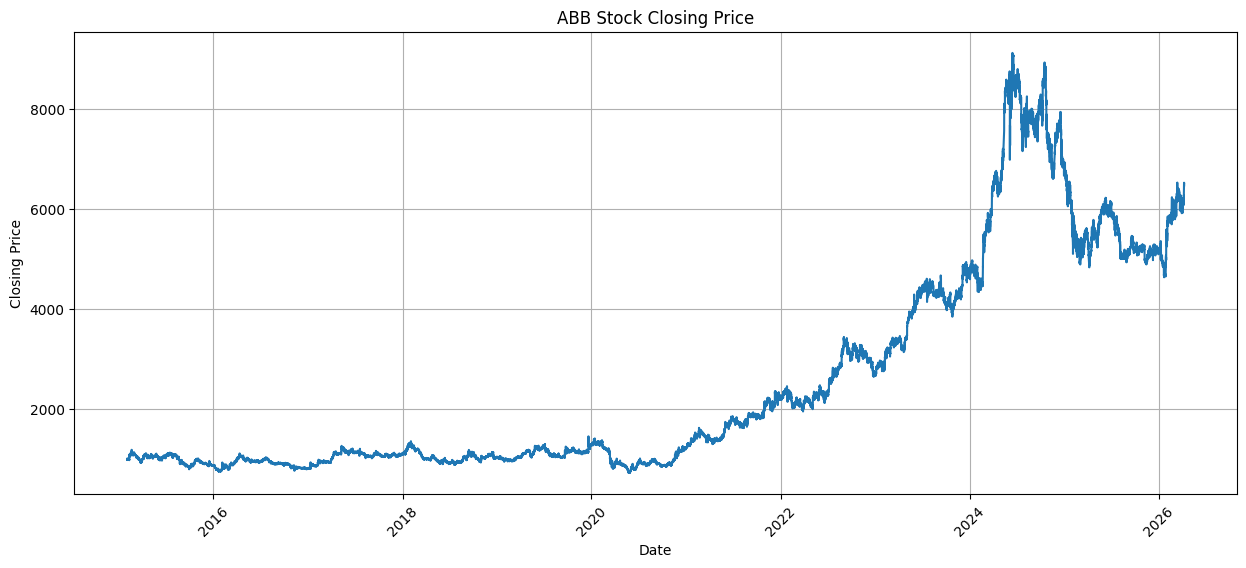

In [17]:
plt.figure(figsize=(15, 6))

plt.plot(
    df["date"],
    df["close"]
)

plt.title("ABB Stock Closing Price")

plt.xlabel("Date")

plt.ylabel("Closing Price")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

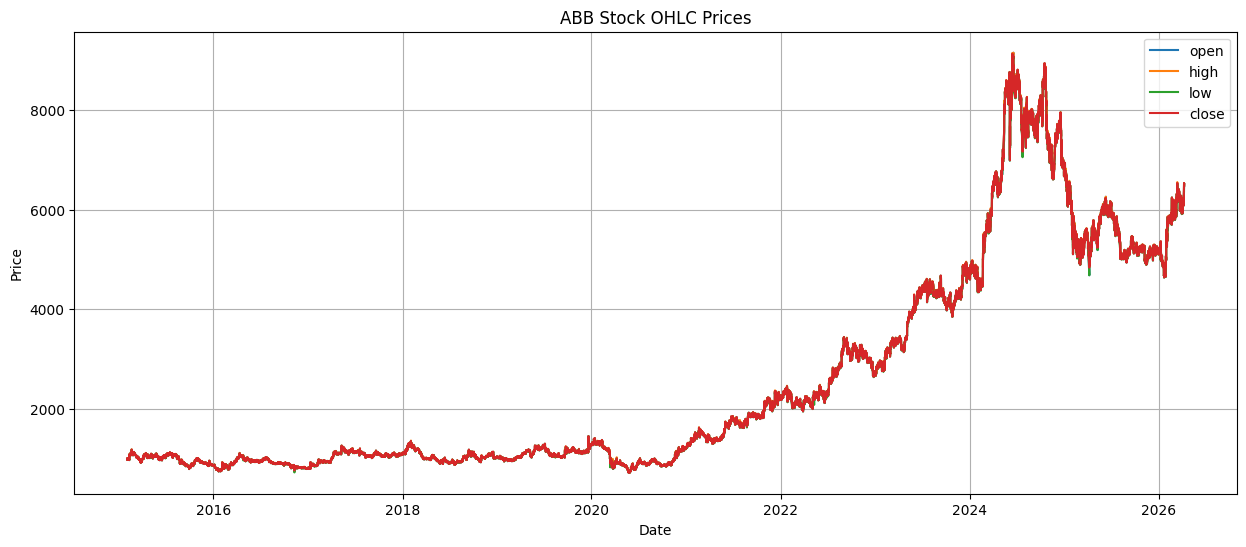

In [18]:
plt.figure(figsize=(15, 6))

plt.plot(df["date"], df["open"], label="open")
plt.plot(df["date"], df["high"], label="high")
plt.plot(df["date"], df["low"], label="low")
plt.plot(df["date"], df["close"], label="close")

plt.title("ABB Stock OHLC Prices")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.show()

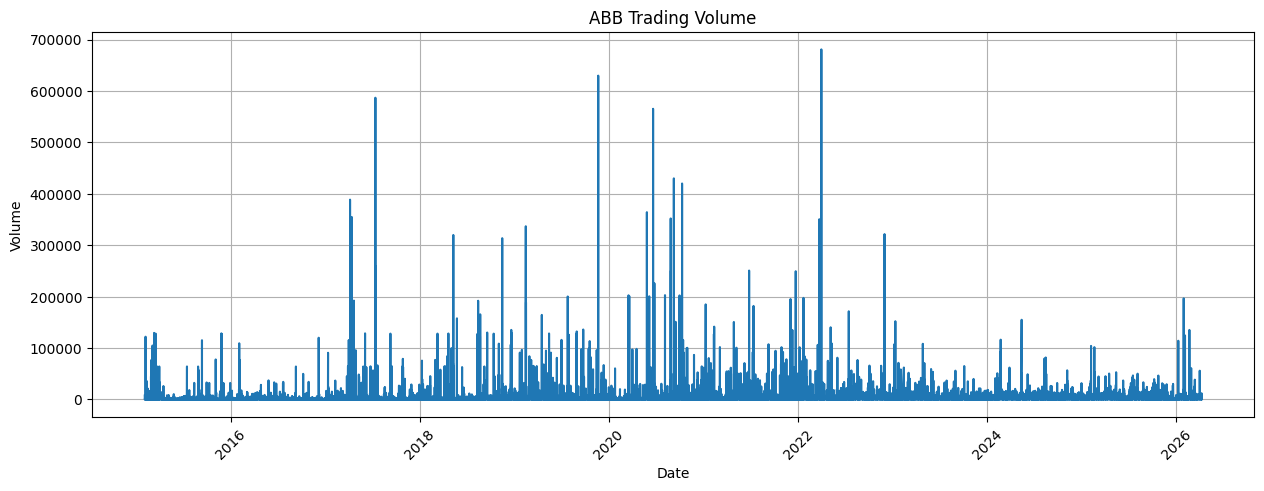

In [19]:
plt.figure(figsize=(15, 5))

plt.plot(
    df["date"],
    df["volume"]
)

plt.title("ABB Trading Volume")

plt.xlabel("Date")

plt.ylabel("Volume")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [20]:
df["MA10"] = df["close"].rolling(window=10).mean()

df["MA20"] = df["close"].rolling(window=20).mean()

df["MA50"] = df["close"].rolling(window=50).mean()

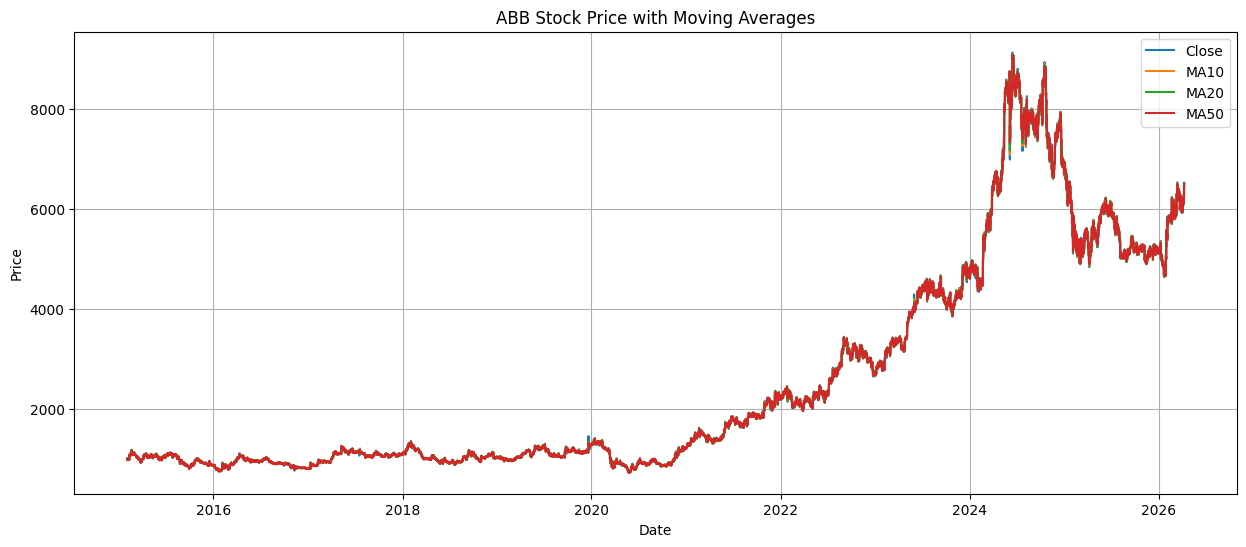

In [21]:
plt.figure(figsize=(15, 6))

plt.plot(
    df["date"],
    df["close"],
    label="Close"
)

plt.plot(
    df["date"],
    df["MA10"],
    label="MA10"
)

plt.plot(
    df["date"],
    df["MA20"],
    label="MA20"
)

plt.plot(
    df["date"],
    df["MA50"],
    label="MA50"
)

plt.title("ABB Stock Price with Moving Averages")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.show()

In [22]:
df["Daily_Return"] = df["close"].pct_change()

In [23]:
df["Price_Range"] = df["high"] - df["low"]

In [24]:
df["Open_Close"] = df["close"] - df["open"]

In [25]:
df["Volatility"] = (
    df["Daily_Return"]
    .rolling(window=20)
    .std()
)

In [26]:
df["Target"] = df["close"].shift(-1)

In [27]:
df = df.dropna()

df = df.reset_index(drop=True)

print(df.shape)

(1031816, 14)


In [28]:
features = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "MA10",
    "MA20",
    "MA50",
    "Daily_Return",
    "Price_Range",
    "Open_Close",
    "Volatility"
]

X = df[features]

y = df["Target"]

print("X shape:", X.shape)

print("y shape:", y.shape)

X shape: (1031816, 12)
y shape: (1031816,)


In [29]:
n = len(df)

train_end = int(n * 0.70)

val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (722271, 12)
Validation: (154772, 12)
Testing: (154773, 12)


In [30]:
from sklearn.linear_model import LinearRegression

In [31]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

LinearRegression()

In [32]:
linear_pred = linear_model.predict(X_test)

In [33]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_pred
    )
)

linear_r2 = r2_score(
    y_test,
    linear_pred
)

print("LINEAR REGRESSION")
print("-----------------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

LINEAR REGRESSION
-----------------------
MAE : 3.7186217469222322
RMSE: 6.305207374480517
R²  : 0.9999616560388485


In [34]:
from sklearn.ensemble import RandomForestRegressor

In [35]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

In [72]:
rf_model.fit(
    X_train,
    y_train
)

RandomForestRegressor(max_depth=15, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [73]:
rf_pred = rf_model.predict(X_test)

In [74]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("RANDOM FOREST")
print("-----------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

RANDOM FOREST
-----------------------
MAE : 2610.466329461523
RMSE: 2802.0865637647594
R²  : -6.572884299523416


In [81]:
comparison = pd.DataFrame({
    "Date": df["date"].iloc[val_end_df:].values,
    "Actual": y_test.values,
    "Predicted": rf_pred
})

comparison.head(20)

,Date,Actual,Predicted
0,2024-08-06 10:20:00,7552.55,3440.356090
1,2024-08-06 10:21:00,7554.10,3440.524932
2,2024-08-06 10:22:00,7543.30,3440.484974
3,2024-08-06 10:23:00,7532.00,3439.529458
4,2024-08-06 10:24:00,7559.00,3439.273583
5,2024-08-06 10:25:00,7572.90,3440.495007
6,2024-08-06 10:26:00,7566.95,3440.495007
7,2024-08-06 10:27:00,7574.35,3439.597983
8,2024-08-06 10:28:00,7565.00,3440.495257
9,2024-08-06 10:29:00,7577.85,3439.529458


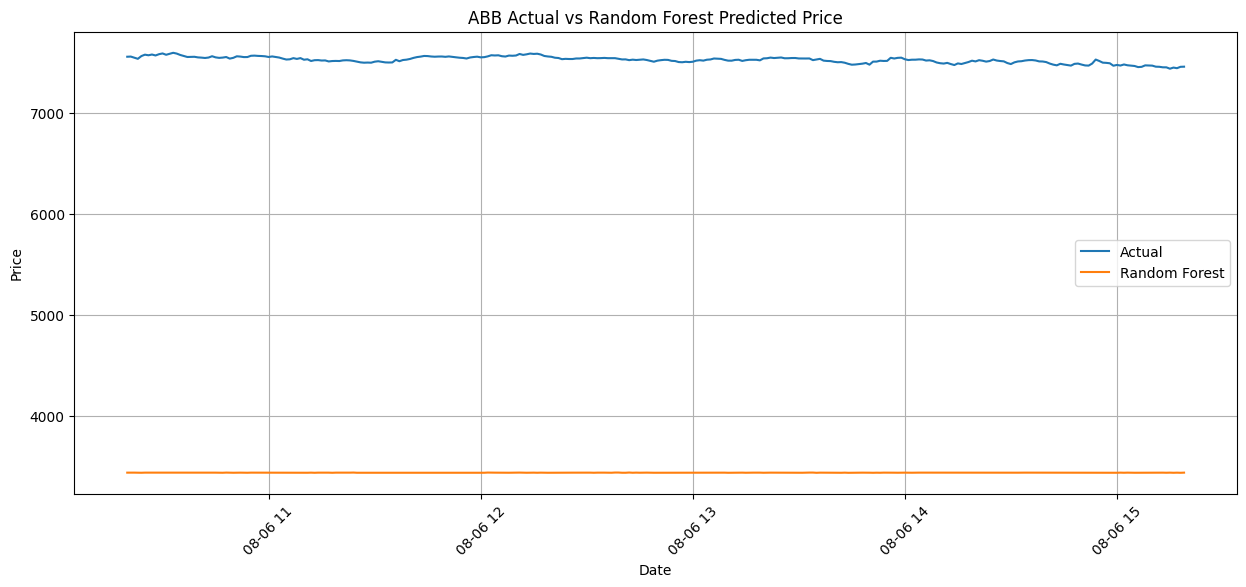

In [82]:
plt.figure(figsize=(15, 6))

plt.plot(
    comparison["Date"][:300],
    comparison["Actual"][:300],
    label="Actual"
)

plt.plot(
    comparison["Date"][:300],
    comparison["Predicted"][:300],
    label="Random Forest"
)

plt.title(
    "ABB Actual vs Random Forest Predicted Price"
)

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [83]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

         Feature    Importance
3          close  9.846454e-01
1           high  9.188753e-03
2            low  5.476327e-03
0           open  4.165046e-04
7           MA50  1.316012e-04
5           MA10  7.176579e-05
6           MA20  6.718911e-05
11    Volatility  6.157141e-07
4         volume  5.633542e-07
9    Price_Range  4.806468e-07
8   Daily_Return  4.353894e-07
10    Open_Close  3.602178e-07


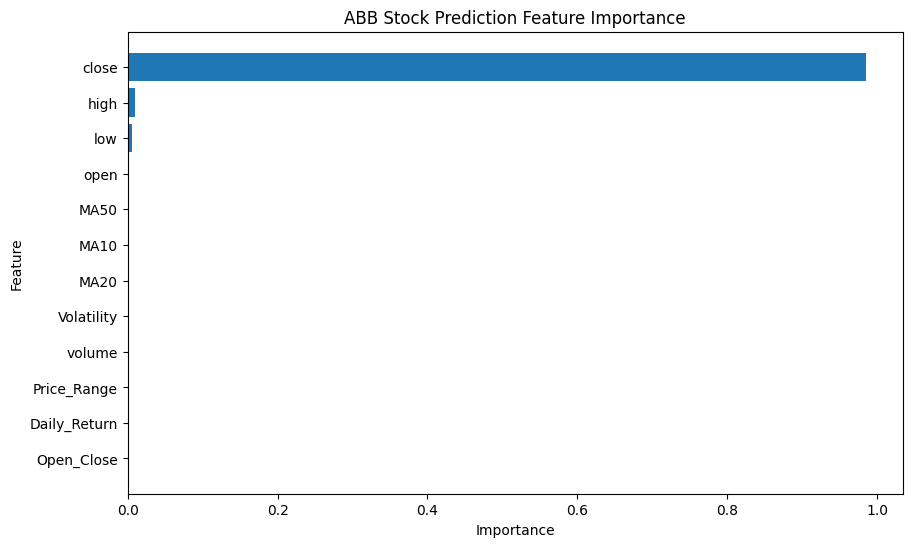

In [84]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("ABB Stock Prediction Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [85]:
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

In [87]:
close_data = df[["close"]].values

scaler = MinMaxScaler(
    feature_range=(0, 1)
)

scaled_data = scaler.fit_transform(
    close_data
)

print(scaled_data[:5])

[[0.03335811]
 [0.03335811]
 [0.03325701]
 [0.03355437]
 [0.03344138]]


In [88]:
sequence_length = 60

X_lstm = []

y_lstm = []

for i in range(
    sequence_length,
    len(scaled_data)
):

    X_lstm.append(
        scaled_data[
            i-sequence_length:i,
            0
        ]
    )

    y_lstm.append(
        scaled_data[i, 0]
    )

X_lstm = np.array(X_lstm)

y_lstm = np.array(y_lstm)

print("X LSTM:", X_lstm.shape)

print("y LSTM:", y_lstm.shape)

X LSTM: (1031756, 60)
y LSTM: (1031756,)


In [89]:
n = len(X_lstm)

train_end = int(n * 0.70)

val_end = int(n * 0.85)

X_train_lstm = X_lstm[:train_end]

y_train_lstm = y_lstm[:train_end]

X_val_lstm = X_lstm[
    train_end:val_end
]

y_val_lstm = y_lstm[
    train_end:val_end
]

X_test_lstm = X_lstm[val_end:]

y_test_lstm = y_lstm[val_end:]

In [90]:
X_train_lstm = X_train_lstm.reshape(
    X_train_lstm.shape[0],
    X_train_lstm.shape[1],
    1
)

X_val_lstm = X_val_lstm.reshape(
    X_val_lstm.shape[0],
    X_val_lstm.shape[1],
    1
)

X_test_lstm = X_test_lstm.reshape(
    X_test_lstm.shape[0],
    X_test_lstm.shape[1],
    1
)

print(X_train_lstm.shape)

(722229, 60, 1)


In [91]:
model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(60, 1)
    )
)

model.add(Dropout(0.2))

model.add(
    LSTM(32)
)

model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [92]:
history = model.fit(
    X_train_lstm,
    y_train_lstm,
    validation_data=(
        X_val_lstm,
        y_val_lstm
    ),
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10
11285/11285 ━━━━━━━━━━━━━━━━━━━━ 124s 11ms/step - loss: 4.9625e-05 - val_loss: 0.0029
Epoch 2/10
11285/11285 ━━━━━━━━━━━━━━━━━━━━ 121s 11ms/step - loss: 4.2145e-05 - val_loss: 0.0223
Epoch 3/10
11285/11285 ━━━━━━━━━━━━━━━━━━━━ 142s 11ms/step - loss: 4.0744e-05 - val_loss: 0.0360
Epoch 4/10
11285/11285 ━━━━━━━━━━━━━━━━━━━━ 120s 11ms/step - loss: 4.0052e-05 - val_loss: 0.0462
Epoch 5/10
11285/11285 ━━━━━━━━━━━━━━━━━━━━ 120s 11ms/step - loss: 3.9890e-05 - val_loss: 0.0502
Epoch 6/10
11285/11285 ━━━━━━━━━━━━━━━━━━━━ 120s 11ms/step - loss: 3.9358e-05 - val_loss: 0.0514
Epoch 7/10
11285/11285 ━━━━━━━━━━━━━━━━━━━━ 131s 12ms/step - loss: 3.9140e-05 - val_loss: 0.0503
Epoch 8/10
11285/11285 ━━━━━━━━━━━━━━━━━━━━ 133s 11ms/step - loss: 3.9236e-05 - val_loss: 0.0567
Epoch 9/10
11285/11285 ━━━━━━━━━━━━━━━━━━━━ 120s 11ms/step - loss: 3.8837e-05 - val_loss: 0.0533
Epoch 10/10
11285/11285 ━━━━━━━━━━━━━━━━━━━━ 141s 11ms/step - loss: 3.8603e-05 - val_loss: 0.0567


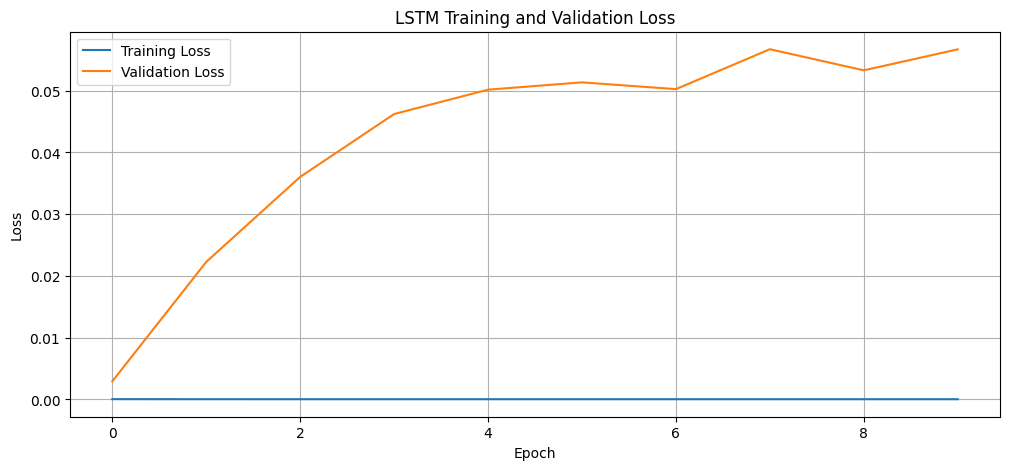

In [93]:
plt.figure(figsize=(12, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training and Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [94]:
lstm_pred_scaled = model.predict(
    X_test_lstm
)

4837/4837 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step


In [95]:
lstm_pred = scaler.inverse_transform(
    lstm_pred_scaled
)

actual_lstm = scaler.inverse_transform(
    y_test_lstm.reshape(-1, 1)
)

In [96]:
lstm_mae = mean_absolute_error(
    actual_lstm,
    lstm_pred
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        actual_lstm,
        lstm_pred
    )
)

lstm_r2 = r2_score(
    actual_lstm,
    lstm_pred
)

print("LSTM")
print("-----------------------")
print("MAE :", lstm_mae)
print("RMSE:", lstm_rmse)
print("R²  :", lstm_r2)

LSTM
-----------------------
MAE : 2373.04896214805
RMSE: 2578.5434788054004
R²  : -5.413152861841947


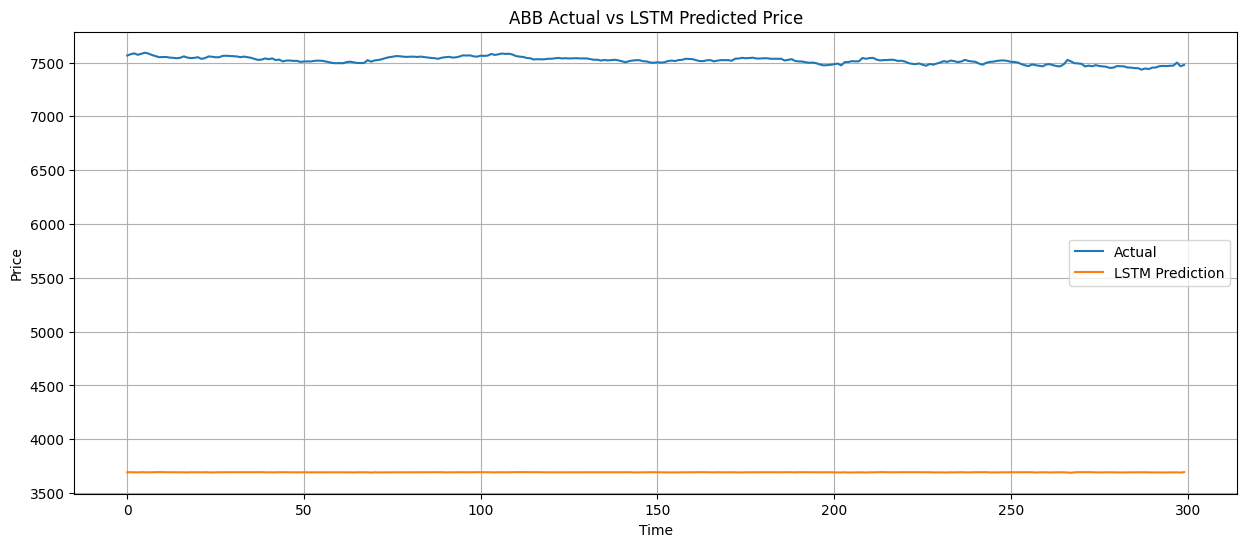

In [97]:
plt.figure(figsize=(15, 6))

plt.plot(
    actual_lstm[:300],
    label="Actual"
)

plt.plot(
    lstm_pred[:300],
    label="LSTM Prediction"
)

plt.title(
    "ABB Actual vs LSTM Predicted Price"
)

plt.xlabel("Time")

plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.show()

In [98]:
results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest",
        "LSTM"
    ],

    "MAE": [
        linear_mae,
        rf_mae,
        lstm_mae
    ],

    "RMSE": [
        linear_rmse,
        rf_rmse,
        lstm_rmse
    ],

    "R2": [
        linear_r2,
        rf_r2,
        lstm_r2
    ]
})

print(results)

               Model          MAE         RMSE        R2
0  Linear Regression     3.718622     6.305207  0.999962
1      Random Forest  2610.466329  2802.086564 -6.572884
2               LSTM  2373.048962  2578.543479 -5.413153


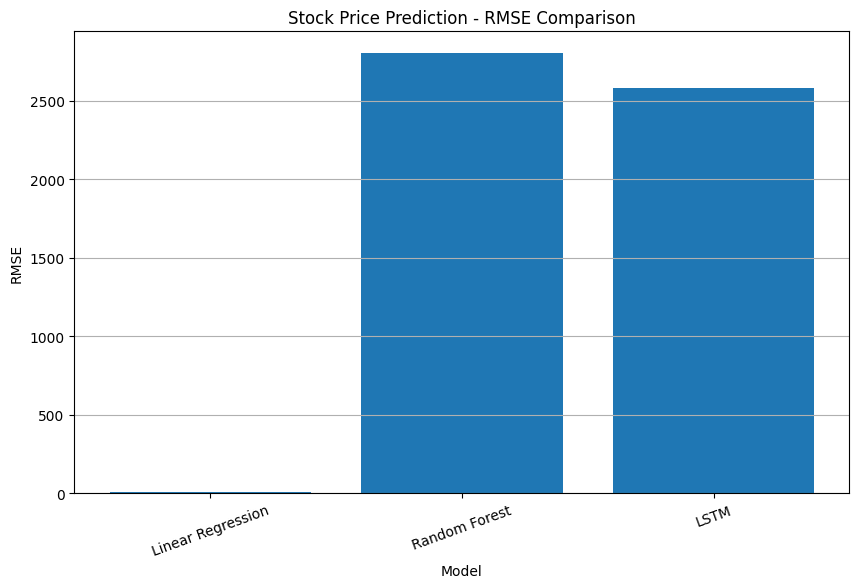

In [99]:
plt.figure(figsize=(10, 6))

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.title("Stock Price Prediction - RMSE Comparison")

plt.xlabel("Model")

plt.ylabel("RMSE")

plt.xticks(rotation=20)

plt.grid(axis="y")

plt.show()

In [100]:
last_60 = scaled_data[-60:]

last_60 = last_60.reshape(
    1,
    60,
    1
)

In [101]:
next_price_scaled = model.predict(
    last_60
)

next_price = scaler.inverse_transform(
    next_price_scaled
)

print(
    "Predicted next ABB closing price:",
    float(next_price[0][0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted next ABB closing price: 3683.989990234375


In [102]:
model.save(
    "/content/ABB_LSTM_model.keras"
)

print("LSTM model saved successfully")

LSTM model saved successfully


In [103]:
results.to_csv(
    "/content/ABB_model_results.csv",
    index=False
)

comparison.to_csv(
    "/content/ABB_predictions.csv",
    index=False
)

print("Results saved successfully")

Results saved successfully


In [104]:
from google.colab import files

files.download("/content/ABB_model_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>